# SOLER Learning Analytics Demonstration

This python notebook will run code that will process your learning analytics data downloaded from your Canvas course and show which categories of Canvas your students are looking at the most.

# Instructions

Download the Canvas Learning Analytics Report by clicking:
1. "Course Analytics" on the left-hand menu
2. "Reports" tab
3. "Run Report" button next to "Course Activity"

Run this notebook with the "Run all" button, and upload your Course Activity Report as prompted

📂 Please upload your Canvas CSV file:


FileUpload(value={}, accept='.csv', description='Upload')


✅ Loaded: activity 3-27-2026 (1).csv
Rows: 34, Columns: 15


,Student Id,Student Name,Sortable Name,Student SIS ID,Section Id,Section Name,Course Id,Course Name,Content Type,Content Name,Times Viewed,Times Participated,Start Date,First Viewed,Last Viewed
0,314182,Soler LDTST 17,"17, Soler LDTST",ldtst0017,212586,SOLER Test Site,221084,SOLER Test Site,course.files.file,PosControlTestResource.docx,1,0,2026-03-20,2026-03-20T15:56:39-04:00,2026-03-20T15:56:39-04:00
1,314178,Soler LDTST 13,"13, Soler LDTST",ldtst0013,212586,SOLER Test Site,221084,SOLER Test Site,course.home,Course Home,3,0,2026-03-20,2026-03-20T15:47:44-04:00,2026-03-20T15:48:19-04:00
2,314182,Soler LDTST 17,"17, Soler LDTST",ldtst0017,212586,SOLER Test Site,221084,SOLER Test Site,course.grades,Course Grades,4,0,2026-03-20,2026-03-20T15:56:17-04:00,2026-03-20T15:57:01-04:00
3,314182,Soler LDTST 17,"17, Soler LDTST",ldtst0017,212586,SOLER Test Site,221084,SOLER Test Site,course.discussions.discussion,Sophia's Test Announcement with Image,2,0,2026-03-20,2026-03-20T15:56:09-04:00,2026-03-20T15:56:10-04:00
4,314178,Soler LDTST 13,"13, Soler LDTST",ldtst0013,212586,SOLER Test Site,221084,SOLER Test Site,course.files.file,OddTestResource.docx,1,0,2026-03-20,2026-03-20T15:48:04-04:00,2026-03-20T15:48:04-04:00


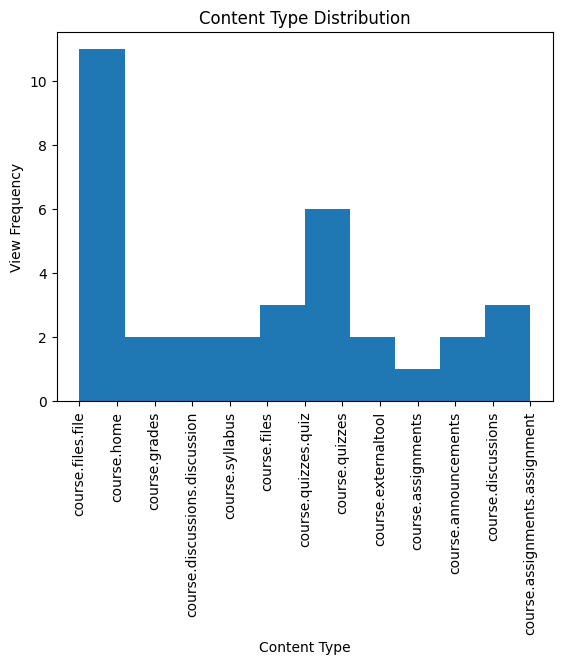

Students saw the following type of content with the listed frequencies:


,count
Content Type,
course.files.file,8
course.home,3
course.quizzes,3
course.quizzes.quiz,3
course.files,3
course.syllabus,2
course.discussions.discussion,2
course.grades,2
course.externaltool,2


In [ ]:
import pandas as pd
import io
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

upload = widgets.FileUpload(accept='.csv', multiple=False)

def handle_upload(change):
    if upload.value:
        file_info = list(upload.value.values())[0]
        filename = file_info['metadata']['name']

        try:
            df = pd.read_csv(io.BytesIO(file_info['content']))

            print(f"\n✅ Loaded: {filename}")
            print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

            display(df.head())

            plt.hist(df['Content Type'])
            plt.xlabel('Content Type')
            plt.ylabel('View Frequency')
            plt.title('Content Type Distribution')
            plt.xticks(rotation=90)
            plt.show()

            freq_table = df['Content Type'].value_counts()
            print("Students saw the following type of content with the listed frequencies:")
            display(freq_table)

        except Exception as e:
            print(f"❌ Error reading file: {e}")

upload.observe(handle_upload, names='value')

print("📂 Please upload your Canvas CSV file:")
display(upload)